# Power Spectrum

In [1]:
import sys
from goa_import import *
HOME='/oscar/data/deeps/private/ediloren/ebeaudin/'

# GLORYS, daily
glorys_path = HOME + 'data/GLORYS_daily/depth_47.37m/'
glorys = xr.open_mfdataset(sorted(glob(glorys_path+'*.nc')))
glorys = glorys.isel(depth=0)

In [2]:
# Transpose signal into frequency space, using Fourier Series

def fourier(signal):
    from scipy.fftpack import fft
    
    sampling_rate = 1 #months
    N = np.size(signal)
    f = np.fft.fft(signal)
    freqs = np.fft.fftfreq(N, 1/sampling_rate)

    nf = f/f.max() # normalized spectrum
    power = 2./N * np.abs(f[0:N//2]) #spectrum to plot
    power = power / np.sum(power) # normalized spectrum
    
    return freqs, power, N

def red_noise(ts, alpha=0.9, beta=1.0):
    from scipy.stats import f
    
    # Parameters
    T = len(ts)
    #alpha = 0.9 # auto-correlation [0=white noise, 1=random walk]
    #beta = 1.0 # noise amplitude/std [1=normal std]
    
    # Generate red noise spectrum (e.g. average over 100 synthetic series)
    n_sim = 100
    spec_sim = []
    
    for _ in range(n_sim):
        x = np.zeros(T)
        x[0] = beta*np.random.randn()
        for j in range(1, T):
            x[j] = alpha * x[j-1] + beta * np.random.randn()
        f_syn = np.fft.fft(x)
        p_syn = 2./T * np.abs(f_syn[0:T//2])
        spec_sim.append(p_syn)
    
    # Average red-noise spectrum
    rspec = np.mean(spec_sim, axis=0)
    rspec = rspec/ np.sum(rspec) # normalize
    
    # F-test significance
    dof = 2
    fstat99 = f.ppf(0.99, dof, 1000)
    spec99 = rspec * fstat99
    
    fstat95 = f.ppf(0.95, dof, 1000)
    spec95 = rspec * fstat95

    fstat90 = f.ppf(0.90, dof, 1000)
    spec90 = rspec * fstat90

    return rspec, spec90, spec95, spec99

In [3]:
def autocorr(x, length=10):
    return np.array([1]+[np.corrcoef(x[:-i], x[i:])[0,1]  \
        for i in range(1, length)])

import os
outdir=f'/oscar/data/deeps/private/ediloren/ebeaudin/particle-tracking/Haida_47.37m_1993-2025/power_spectra'
os.makedirs(outdir, exist_ok=True)
print(outdir)

KE = 0.5*(glorys.uo**2 + glorys.vo**2)

for i in range(0,KE.longitude.size,10):
    for j in range(0,KE.latitude.size,10):
        lat,lon = KE.isel(latitude=j).latitude.item(), KE.isel(longitude=i).longitude.item()
        outfile=f"{outdir}/KE_spectrum_{np.round(lat,2)}N_{-np.round(lon,2)}W.nc"

        if not os.path.exists(outfile):
            print(f"Saving {outfile}")
            
            ts = KE.isel(latitude=j, longitude=i).resample(time='1MS').mean('time').load()
            ts_ano = anomalies(ts)
            
            alpha = autocorr(ts_ano)[1]
            beta = ts_ano.std() * np.sqrt(1 - alpha**2)
            
            freqs, power, N = fourier(ts_ano)
            rspec, spec90, spec95, spec99 = red_noise(ts_ano, alpha=alpha, beta=beta)
    
            years = 1/(12*freqs[:N//2])
            
            # Save dataset
            ds_out = xr.Dataset(
                {
                    "KE": (["time"], ts.values),
                    "power": (["freq"], power),
                    "rspec": (["freq"], rspec),
                    "spec90": (["freq"], spec90),
                    "spec95": (["freq"], spec95),
                    "spec99": (["freq"], spec99),
                    "years": (["freq"], years),
                },
                coords={
                    "time": ts.time,
                    "freq": freqs[:N//2],
                    "lat": ("lat", [KE.latitude[j].item()]),
                    "lon": ("lon", [KE.longitude[i].item()]),
                },
                attrs={
                    "description": "Power spectrum of KE with red-noise significance",
                    "depth": str(ts.depth.values),
                    "alpha": float(alpha),
                    "beta": float(beta),
                }
                )
            ds_out.to_netcdf(outfile)

/oscar/data/deeps/private/ediloren/ebeaudin/particle-tracking/Haida_47.37m_1993-2025/power_spectra
Saving /oscar/data/deeps/private/ediloren/ebeaudin/particle-tracking/Haida_47.37m_1993-2025/power_spectra/KE_spectrum_60.83N_169.17W.nc


/oscar/data/ediloren/ebeaudin/myenv/lib64/python3.9/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/tmp/ipykernel_3131951/1713356136.py:11: RuntimeWarning: invalid value encountered in divide
  nf = f/f.max() # normalized spectrum
/tmp/ipykernel_3131951/3246141622.py:29: RuntimeWarning: divide by zero encountered in divide
  years = 1/(12*freqs[:N//2])


Saving /oscar/data/deeps/private/ediloren/ebeaudin/particle-tracking/Haida_47.37m_1993-2025/power_spectra/KE_spectrum_61.67N_169.17W.nc


/tmp/ipykernel_3131951/3246141622.py:29: RuntimeWarning: divide by zero encountered in divide
  years = 1/(12*freqs[:N//2])


Saving /oscar/data/deeps/private/ediloren/ebeaudin/particle-tracking/Haida_47.37m_1993-2025/power_spectra/KE_spectrum_45.0N_168.33W.nc


...

/oscar/data/ediloren/ebeaudin/myenv/lib64/python3.9/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/tmp/ipykernel_3131951/1713356136.py:11: RuntimeWarning: invalid value encountered in divide
  nf = f/f.max() # normalized spectrum
/tmp/ipykernel_3131951/3246141622.py:29: RuntimeWarning: divide by zero encountered in divide
  years = 1/(12*freqs[:N//2])


Saving /oscar/data/deeps/private/ediloren/ebeaudin/particle-tracking/Haida_47.37m_1993-2025/power_spectra/KE_spectrum_60.83N_122.5W.nc


/oscar/data/ediloren/ebeaudin/myenv/lib64/python3.9/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/tmp/ipykernel_3131951/1713356136.py:11: RuntimeWarning: invalid value encountered in divide
  nf = f/f.max() # normalized spectrum
/tmp/ipykernel_3131951/3246141622.py:29: RuntimeWarning: divide by zero encountered in divide
  years = 1/(12*freqs[:N//2])


Saving /oscar/data/deeps/private/ediloren/ebeaudin/particle-tracking/Haida_47.37m_1993-2025/power_spectra/KE_spectrum_61.67N_122.5W.nc


/oscar/data/ediloren/ebeaudin/myenv/lib64/python3.9/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/tmp/ipykernel_3131951/1713356136.py:11: RuntimeWarning: invalid value encountered in divide
  nf = f/f.max() # normalized spectrum
/tmp/ipykernel_3131951/3246141622.py:29: RuntimeWarning: divide by zero encountered in divide
  years = 1/(12*freqs[:N//2])


In [5]:
# merge all
files = sorted(glob(HOME+'particle-tracking/Haida_47.37m_1993-2025/power_spectra/*.nc'))
files

%time KE_all = xr.open_mfdataset(files)
KE_all

CPU times: user 19.1 s, sys: 781 ms, total: 19.9 s
Wall time: 37.5 s


<xarray.Dataset>
Dimensions:    (lon: 58, lat: 21, time: 388, freq: 194)
Coordinates:
    depth      float32 47.37
    latitude   (lat) float32 45.0 45.83 46.67 47.5 ... 59.17 60.0 60.83 61.67
    longitude  (lon) float32 -170.0 -169.2 -168.3 ... -124.2 -123.3 -122.5
  * time       (time) datetime64[ns] 1993-01-01 1993-02-01 ... 2025-04-01
  * freq       (freq) float64 0.0 0.002577 0.005155 ... 0.4923 0.4948 0.4974
  * lat        (lat) float64 45.0 45.83 46.67 47.5 ... 59.17 60.0 60.83 61.67
  * lon        (lon) float64 -170.0 -169.2 -168.3 ... -124.2 -123.3 -122.5
Data variables:
    KE         (lon, lat, time) float32 dask.array<chunksize=(1, 1, 388), meta=np.ndarray>
    power      (lon, lat, freq) float64 dask.array<chunksize=(1, 1, 194), meta=np.ndarray>
    rspec      (lon, lat, freq) float64 dask.array<chunksize=(1, 1, 194), meta=np.ndarray>
    spec90     (lon, lat, freq) float64 dask.array<chunksize=(1, 1, 194), meta=np.ndarray>
    spec95     (lon, lat, freq) float64 dask.array<chunksize=(1, 1, 194), meta=np.ndarray>
    spec99     (lon, lat, freq) float64 dask.array<chunksize=(1, 1, 194), meta=np.ndarray>
    years      (lon, lat, freq) float64 dask.array<chunksize=(1, 1, 194), meta=np.ndarray>
Attributes:
    description:  Power spectrum of KE with red-noise significance
    depth:        47.37369
    alpha:        0.4942923583508951
    beta:         0.002529118701811248

In [6]:
KE_all.to_netcdf(HOME+'particle-tracking/Haida_47.37m_1993-2025/power_spectra/KE_spectrum_merged.nc')

/tmp/ipykernel_3106342/63053350.py:8: RuntimeWarning: divide by zero encountered in divide
  years = 1/(12*freqs[:N//2]) # convert frequencies [1/month] into years


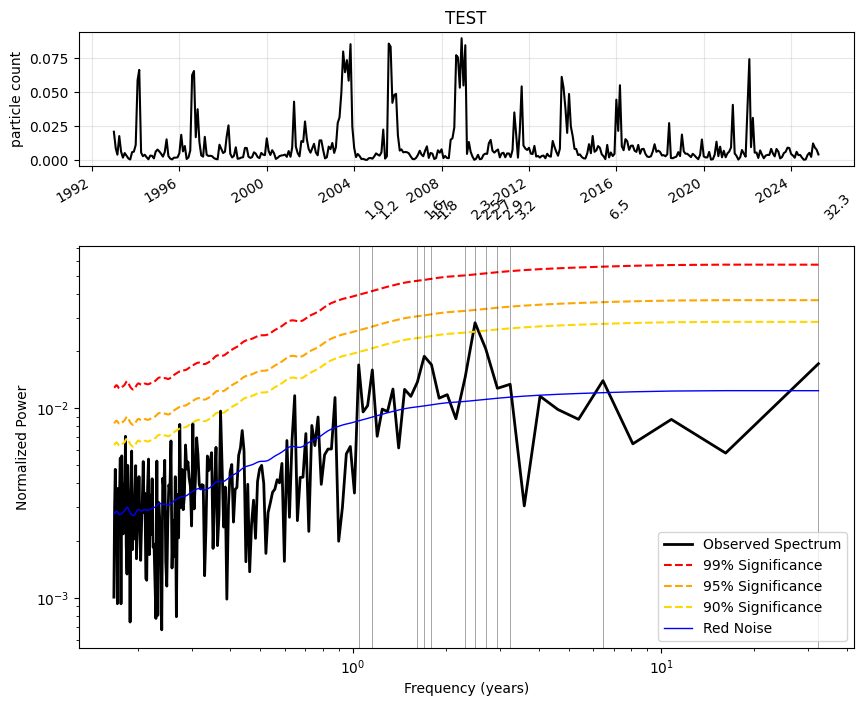

In [55]:
#ts = ts8.rolling(time=1,center=True).mean('time') # choose timeseries
#ts = ts[~np.isnan(ts)]
title = 'TEST'

#ano = anomalies(ts,ref_times=slice('2000','2025')) # compute anomalies
#freqs, power, N = fourier(ano) # compute power spectrum

years = 1/(12*freqs[:N//2]) # convert frequencies [1/month] into years
#rspec, spec90, spec95, spec99 = red_noise(ts) # compute significance from red noise

# Plot spectrum with significance tests
fig, ax = plt.subplots(2, 1, figsize=(10,8), gridspec_kw={'height_ratios': [1, 3],
                                                          'hspace': 0.3})

axis=ax[0]
ts.plot(color='k', ax=axis) # timeseries
axis.grid(alpha=0.3)
axis.set_title(title); axis.set_xlabel(''); axis.set_ylabel('particle count')
#add_enso(axis); add_mhws(axis)

axis=ax[1]
axis.plot(years, gaussian_filter(power, 0), 'k-', linewidth=2, label='Observed Spectrum')
axis.plot(years, gaussian_filter(spec99,2), 'r', linestyle='--', label='99% Significance')
axis.plot(years, gaussian_filter(spec95,2), 'orange', linestyle='--', label='95% Significance')
axis.plot(years, gaussian_filter(spec90,2), 'gold', linestyle='--', label='90% Significance')
axis.plot(years, gaussian_filter(rspec, 2), 'b-', linewidth=1, label='Red Noise')

plt.legend()
plt.xlabel('Frequency (years)')
#plt.grid(alpha=0.3)
plt.xscale('log'); plt.yscale('log')
#plt.title('Power Spectrum for {title}')
imax = np.argsort(power)[-12:]
text_height = 0.1
for i in imax:
    plt.axvline(years[i], color='k', linestyle='-', alpha=0.5, linewidth=0.5)
    plt.text(years[i]*1.03, text_height, f'{np.round(years[i],1)}', zorder=101, color='k', fontsize=10, rotation=45)
#axis.ylim(0, 0.15)
#axis.set_xlim(0,12)
axis.set_ylabel('Normalized Power')
plt.show();